In [59]:
import pandas as pd
import numpy as np

from google.colab import files

In [60]:
df = pd.read_csv('heart_attack_prediction_dataset.csv')

print('df is loaded')
df.shape

df is loaded


(8763, 26)

In [61]:
df.head()

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
0,BMW7812,67,Male,208,158/88,72,0,0,1,0,...,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0
1,CZE1114,21,Male,389,165/93,98,1,1,1,1,...,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0
2,BNI9906,21,Female,324,174/99,72,1,0,0,0,...,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0
3,JLN3497,84,Male,383,163/100,73,1,1,1,0,...,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0
4,GFO8847,66,Male,318,91/88,93,1,1,1,1,...,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0


In [62]:
df.sample(5)

,Patient ID,Age,Sex,Cholesterol,Blood Pressure,Heart Rate,Diabetes,Family History,Smoking,Obesity,...,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk
3847,ZYD5391,40,Male,351,176/62,103,0,0,1,0,...,3.362173,40768,22.220320,503,3,5,France,Europe,Northern Hemisphere,0
2506,DXQ6733,30,Male,222,167/91,70,1,0,1,1,...,5.058553,297276,26.300359,594,6,4,United Kingdom,Europe,Northern Hemisphere,0
1590,FBB3727,42,Male,243,156/83,54,1,1,1,0,...,7.836361,222352,26.099599,98,4,4,Vietnam,Asia,Northern Hemisphere,1
5102,JFA8065,37,Female,305,149/90,106,1,0,0,0,...,11.148261,242077,24.520609,94,3,5,Italy,Europe,Southern Hemisphere,1
7591,DAL6612,28,Female,378,142/66,104,1,0,0,1,...,10.586645,202776,25.121614,479,3,7,Japan,Asia,Northern Hemisphere,0


In [63]:
df.columns

Index(['Patient ID', 'Age', 'Sex', 'Cholesterol', 'Blood Pressure',
       'Heart Rate', 'Diabetes', 'Family History', 'Smoking', 'Obesity',
       'Alcohol Consumption', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk'],
      dtype='object')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Patient ID                       8763 non-null   object 
 1   Age                              8763 non-null   int64  
 2   Sex                              8763 non-null   object 
 3   Cholesterol                      8763 non-null   int64  
 4   Blood Pressure                   8763 non-null   object 
 5   Heart Rate                       8763 non-null   int64  
 6   Diabetes                         8763 non-null   int64  
 7   Family History                   8763 non-null   int64  
 8   Smoking                          8763 non-null   int64  
 9   Obesity                          8763 non-null   int64  
 10  Alcohol Consumption              8763 non-null   int64  
 11  Exercise Hours Per Week          8763 non-null   float64
 12  Diet                

In [65]:
df.describe()

,Age,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,53.707977,259.877211,75.021682,0.652288,0.492982,0.896839,0.501426,0.598083,10.014284,0.495835,0.498345,5.469702,5.993690,158263.181901,28.891446,417.677051,3.489672,7.023508,0.358211
std,21.249509,80.863276,20.550948,0.476271,0.499979,0.304186,0.500026,0.490313,5.783745,0.500011,0.500026,2.859622,3.466359,80575.190806,6.319181,223.748137,2.282687,1.988473,0.479502
min,18.000000,120.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.002442,0.000000,0.000000,1.000000,0.001263,20062.000000,18.002337,30.000000,0.000000,4.000000,0.000000
25%,35.000000,192.000000,57.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.981579,0.000000,0.000000,3.000000,2.998794,88310.000000,23.422985,225.500000,2.000000,5.000000,0.000000
50%,54.000000,259.000000,75.000000,1.000000,0.000000,1.000000,1.000000,1.000000,10.069559,0.000000,0.000000,5.000000,5.933622,157866.000000,28.768999,417.000000,3.000000,7.000000,0.000000
75%,72.000000,330.000000,93.000000,1.000000,1.000000,1.000000,1.000000,1.000000,15.050018,1.000000,1.000000,8.000000,9.019124,227749.000000,34.324594,612.000000,5.000000,9.000000,1.000000
max,90.000000,400.000000,110.000000,1.000000,1.000000,1.000000,1.000000,1.000000,19.998709,1.000000,1.000000,10.000000,11.999313,299954.000000,39.997211,800.000000,7.000000,10.000000,1.000000


In [66]:
df.isna().sum()

,0
Patient ID,0
Age,0
Sex,0
Cholesterol,0
Blood Pressure,0
Heart Rate,0
Diabetes,0
Family History,0
Smoking,0
Obesity,0


In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
df.drop(columns=['Patient ID'],inplace=True)

In [69]:
df['in_bad_habit'] = df['Smoking'] + df['Alcohol Consumption']
df.drop(columns=['Smoking','Alcohol Consumption'],inplace=True)

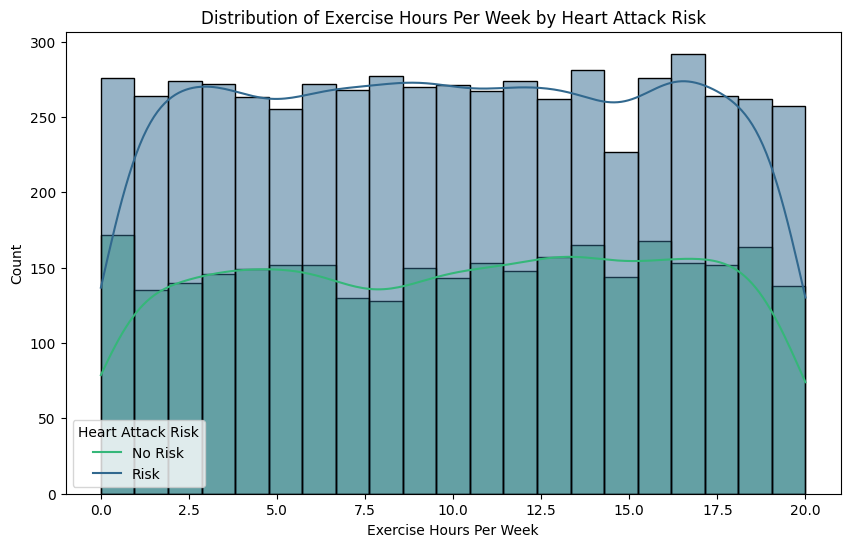

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Exercise Hours Per Week', hue='Heart Attack Risk', kde=True, palette='viridis')
plt.title('Distribution of Exercise Hours Per Week by Heart Attack Risk')
plt.xlabel('Exercise Hours Per Week')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'Risk'])
plt.show()

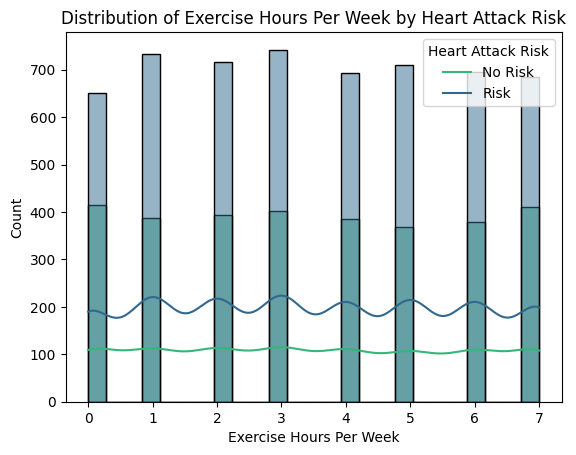

In [71]:
sns.histplot(data=df, x='Physical Activity Days Per Week', hue='Heart Attack Risk', kde=True, palette='viridis')
plt.title('Distribution of Exercise Hours Per Week by Heart Attack Risk')
plt.xlabel('Exercise Hours Per Week')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'Risk'])
plt.show()

In [72]:
# df['Heart Rate'].plot(kind='hist', bins=20, title='Heart Rate Distribution')
# plt.xlabel('Heart Rate')
# plt.ylabel('Frequency')

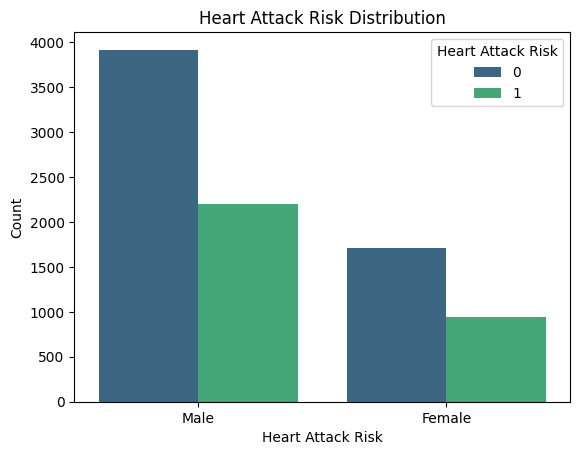

In [73]:
sns.countplot(data=df, x='Sex',palette='viridis',hue='Heart Attack Risk')
plt.title('Heart Attack Risk Distribution')
plt.xlabel('Heart Attack Risk')
plt.ylabel('Count')
plt.show()

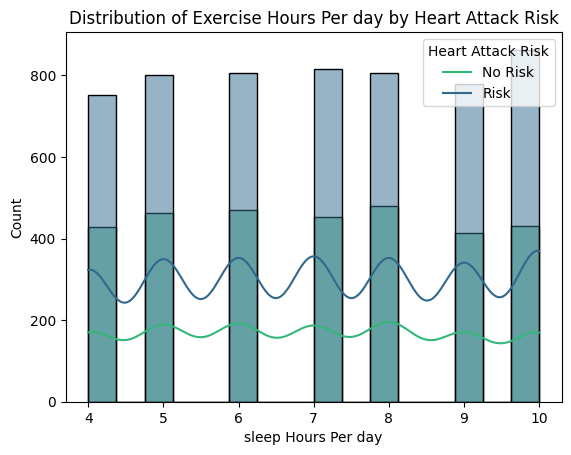

In [74]:
sns.histplot(data=df, x='Sleep Hours Per Day', hue='Heart Attack Risk', kde=True, palette='viridis')
plt.title('Distribution of Exercise Hours Per day by Heart Attack Risk')
plt.xlabel('sleep Hours Per day')
plt.ylabel('Count')
plt.legend(title='Heart Attack Risk', labels=['No Risk', 'Risk'])
plt.show()

In [75]:
df['BMI']

,BMI
0,31.251233
1,27.194973
2,28.176571
3,36.464704
4,21.809144
...,...
8758,19.655895
8759,23.993866
8760,35.406146
8761,27.294020


In [76]:
df['Previous Heart Problems'].unique()

array([0, 1])

In [77]:
df['Medication Use'].unique()

array([0, 1])

In [78]:
df['Stress Level'].unique()

array([ 9,  1,  6,  2,  7,  4,  5,  8, 10,  3])

In [79]:
df.columns

Index(['Age', 'Sex', 'Cholesterol', 'Blood Pressure', 'Heart Rate', 'Diabetes',
       'Family History', 'Obesity', 'Exercise Hours Per Week', 'Diet',
       'Previous Heart Problems', 'Medication Use', 'Stress Level',
       'Sedentary Hours Per Day', 'Income', 'BMI', 'Triglycerides',
       'Physical Activity Days Per Week', 'Sleep Hours Per Day', 'Country',
       'Continent', 'Hemisphere', 'Heart Attack Risk', 'in_bad_habit'],
      dtype='object')

In [80]:
# family history --can be removed
# Continent	Hemisphere
# Physical Activity Days Per Week or Exercise Hours Per Week one can be removed ----- second one can be removed and then we will make the binning technique at the physical activity
# diabaties can be added into bad habit as which person smokes then alcohol consumption then dibates all this only increase the chances of the risk
# gender is fairely imbalanced but it is true so should do about that
# can use the blood pressure and heart rate ---- Cardiovascular Risk & Strain Score  Utilize algorithms like Rate Pressure Product (RPP), calculated as:RPP = HR × SBP(where HR is Heart Rate and SBP is Systolic Blood Pressure)
# income i think is use less as bmi and bp are much imp fetures than income , income cannot descibe the herat risk as high income can provide stress where as low income can provide low quality food diet
# obesity can also be added to bad habit -- remane it to risk score
# i think bmi can be removed as obesity is tell by bmi and bmi is now i think use less
# i will think about diet feature
# previous heart probelm aslo added to the bad habit ( risk score )
# medical use can be keep or change we will figure it out not sure yet
# stress level can be change to binning and then used
# 150 to 199 is border line which can then added to the risk score .

In [81]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ','_',regex=False)

In [82]:
# family history --can be removed
df.drop(columns=['family_history'],inplace=True)

In [83]:
# remove Continent	Hemisphere
df.drop(columns=['continent', 'hemisphere'],inplace=True)

In [84]:
# # Physical Activity Days Per Week or Exercise Hours Per Week one can be removed ---- and binning
# df.drop(columns=['physical_activity_days_per_week'],inplace=True)
# # binning
# df['exercise_hours_per_week'] = pd.cut(df['exercise_hours_per_week'], bins=[0, 6.6, 13.2, np.inf], labels=['Low', 'Medium', 'High'])
df.drop(columns=['exercise_hours_per_week'],inplace=True)

In [85]:
# sns.countplot(df['exercise_hours_per_week'])

In [86]:
# diabaties can be added into bad habit as which person smokes then alcohol consumption then dibates all this only increase the chances of the risk
df['in_bad_habit'] = df['in_bad_habit'] + df['diabetes']
df.drop(columns=['diabetes'],inplace=True)

In [87]:
# can use the blood pressure and heart rate ---- Cardiovascular Risk & Strain Score  Utilize algorithms like Rate Pressure Product (RPP), calculated as:RPP = HR × SBP(where HR is Heart Rate and SBP is Systolic Blood Pressure)
df['systolic_blood_pressure'] = df['blood_pressure'].str.split('/',expand=True)[0]
df['systolic_blood_pressure'] = pd.to_numeric(df['systolic_blood_pressure'])

df['RPF'] = df['heart_rate'] * df['systolic_blood_pressure']
df.drop(columns=['blood_pressure','systolic_blood_pressure','heart_rate'],inplace=True)
df['RPF']


# Low Risk: \(< 10,000\) to \(14,999\)
# Intermediate Risk: \(20,000\) – \(24,999\)
# High Strain/Risk: \(\geq 25,000\) (indicates high cardiac workload or oxygen)

map = {
    (0, 10000): 'Low Risk',
    (10000, 15000): 'Intermediate Risk',
    (15000, np.inf): 'High Risk'
}

df['RPF'] = df['RPF'].apply(lambda x: next((v for k, v in map.items() if k[0] <= x <= k[1]), 'Unknown'))


In [88]:
df['RPF'].unique()

array(['Intermediate Risk', 'High Risk', 'Low Risk'], dtype=object)

<Axes: xlabel='count', ylabel='RPF'>

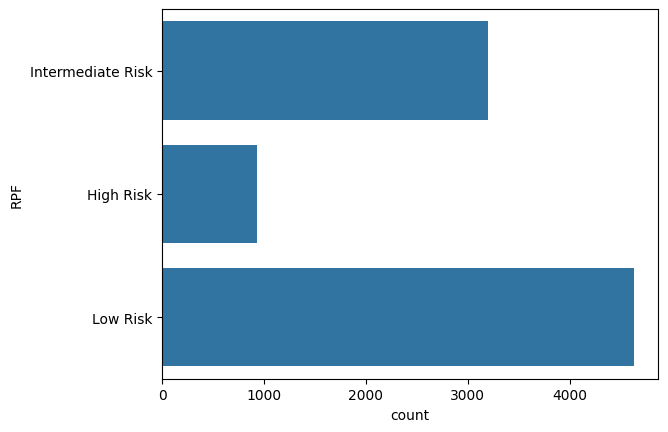

In [89]:
sns.countplot(df['RPF'])

In [90]:
df.rename(columns={'in_bad_habit':'risk_score'},inplace=True)

In [91]:
# income i think is use less
df.drop(columns=['income'],inplace=True)
df.columns

Index(['age', 'sex', 'cholesterol', 'obesity', 'diet',
       'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day', 'country',
       'heart_attack_risk', 'risk_score', 'RPF'],
      dtype='object')

In [92]:
# obesity can also be added to bad habit -- remane it to risk score
df['risk_score'] = df['risk_score'] + df['obesity']
df.drop(columns=['obesity'],inplace=True)

In [93]:
#bmi and diet feature

# df[['diet','bmi']]
# df.drop(columns=['bmi'],inplace=True)

In [94]:
# previous heart probelm
df['risk_score'] =df['risk_score'] + df['previous_heart_problems']
df.drop(columns=['previous_heart_problems'],inplace=True)

In [95]:
another = df.copy()

In [96]:
df['sedentary_hours_per_day'] = np.where(df['sedentary_hours_per_day']>8 ,'High','Low')

In [97]:
df["cholesterol"] = np.where(df["cholesterol"] > 200, "High Chol", "Normal Chol")
df["triglycerides"] = np.where(df["triglycerides"] > 150, "High TG", "Normal TG")
df.drop(columns=['cholesterol','triglycerides'],inplace=True)

In [98]:
df['sex'] = df['sex'].map({'Female': 0, 'Male': 1})
df['sedentary_hours_per_day'] = df['sedentary_hours_per_day'].map({'Low': 0, 'High': 1})
# df['exercise_hours_per_week'] = df['exercise_hours_per_week'].map({'Low': 0, 'Medium':1, 'High': 2})
df['diet'] = df['diet'].map({'Unhealthy': 0, 'Average': 1, 'Healthy': 2})
# df['cholesterol'] = df['cholesterol'].map({'Normal Chol': 0, 'High Chol': 1})
# df['triglycerides'] = df['triglycerides'].map({'Normal TG': 0, 'High TG': 1})
df['RPF'] = df['RPF'].map({'Low Risk': 0, 'Intermediate Risk': 1, 'High Risk': 2})

df.drop(columns=['country'], inplace=True)

In [99]:
cleaned_df = df.copy()

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Separate features (X) and target (y)
X = cleaned_df.drop('heart_attack_risk', axis=1)
y = cleaned_df['heart_attack_risk']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest Classifier Performance:
Accuracy: 0.6177
Precision: 0.3704
Recall: 0.0955
F1-Score: 0.1519

Confusion Matrix:
[[1534  153]
 [ 852   90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.91      0.75      1687
           1       0.37      0.10      0.15       942

    accuracy                           0.62      2629
   macro avg       0.51      0.50      0.45      2629
weighted avg       0.55      0.62      0.54      2629



/tmp/ipykernel_667/3687303409.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


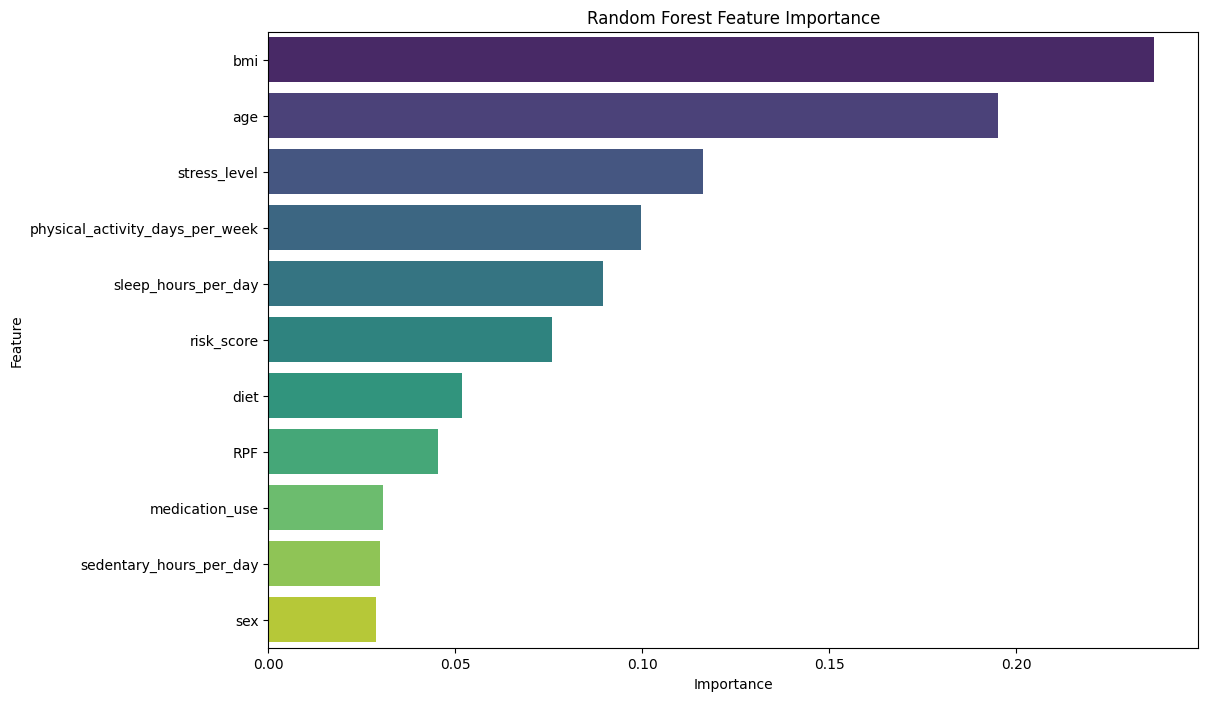

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Create a Series with feature names and their importances
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [102]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize and train the LightGBM Classifier
lgbm_model = LGBMClassifier(random_state=42, verbose=-1) # verbose=-1 to suppress training output
lgbm_model.fit(X_train, y_train)

# Make predictions on the test set
lgbm_y_pred = lgbm_model.predict(X_test)

# Evaluate the LightGBM model
print("\nLightGBM Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, lgbm_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, lgbm_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, lgbm_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, lgbm_y_pred):.4f}")

print("\nLightGBM Confusion Matrix:")
print(confusion_matrix(y_test, lgbm_y_pred))

print("\nLightGBM Classification Report:")
print(classification_report(y_test, lgbm_y_pred))


LightGBM Classifier Performance:
Accuracy: 0.6166
Precision: 0.3625
Recall: 0.0924
F1-Score: 0.1472

LightGBM Confusion Matrix:
[[1534  153]
 [ 855   87]]

LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.91      0.75      1687
           1       0.36      0.09      0.15       942

    accuracy                           0.62      2629
   macro avg       0.50      0.50      0.45      2629
weighted avg       0.54      0.62      0.54      2629



### Addressing Class Imbalance with SMOTE

To improve the model's ability to identify the minority class (heart attack risk = 1), I will use the Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples of the minority class in the training dataset.

In [103]:
from imblearn.over_sampling import SMOTE

print(f"Original training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Original class distribution in training set:\n{y_train.value_counts()}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Resampled training set shape: X_train_res={X_train_res.shape}, y_train_res={y_train_res.shape}")
print(f"Resampled class distribution in training set:\n{y_train_res.value_counts()}")

Original training set shape: X_train=(6134, 11), y_train=(6134,)
Original class distribution in training set:
heart_attack_risk
0    3937
1    2197
Name: count, dtype: int64
Resampled training set shape: X_train_res=(7874, 11), y_train_res=(7874,)
Resampled class distribution in training set:
heart_attack_risk
1    3937
0    3937
Name: count, dtype: int64


### Retraining Random Forest Classifier on Balanced Data

Now, I will retrain the Random Forest Classifier using the SMOTE-resampled training data and evaluate its performance again.

In [104]:
# Initialize and train the Random Forest Classifier on resampled data
model_resampled_rf = RandomForestClassifier(random_state=42)
model_resampled_rf.fit(X_train_res, y_train_res)

# Make predictions on the original test set
y_pred_resampled_rf = model_resampled_rf.predict(X_test)

# Evaluate the model
print("Random Forest Classifier Performance (after SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_resampled_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_resampled_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_resampled_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_resampled_rf):.4f}")

print("\nConfusion Matrix (after SMOTE):")
print(confusion_matrix(y_test, y_pred_resampled_rf))

print("\nClassification Report (after SMOTE):")
print(classification_report(y_test, y_pred_resampled_rf))

Random Forest Classifier Performance (after SMOTE):
Accuracy: 0.5458
Precision: 0.3548
Recall: 0.3270
F1-Score: 0.3403

Confusion Matrix (after SMOTE):
[[1127  560]
 [ 634  308]]

Classification Report (after SMOTE):
              precision    recall  f1-score   support

           0       0.64      0.67      0.65      1687
           1       0.35      0.33      0.34       942

    accuracy                           0.55      2629
   macro avg       0.50      0.50      0.50      2629
weighted avg       0.54      0.55      0.54      2629



### Retraining LightGBM Classifier on Balanced Data

Next, I will retrain the LightGBM Classifier using the SMOTE-resampled training data and evaluate its performance.

In [105]:
# Initialize and train the LightGBM Classifier on resampled data
lgbm_model_resampled = LGBMClassifier(random_state=42, verbose=-1)
lgbm_model_resampled.fit(X_train_res, y_train_res)

# Make predictions on the original test set
lgbm_y_pred_resampled = lgbm_model_resampled.predict(X_test)

# Evaluate the LightGBM model
print("LightGBM Classifier Performance (after SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, lgbm_y_pred_resampled):.4f}")
print(f"Precision: {precision_score(y_test, lgbm_y_pred_resampled):.4f}")
print(f"Recall: {recall_score(y_test, lgbm_y_pred_resampled):.4f}")
print(f"F1-Score: {f1_score(y_test, lgbm_y_pred_resampled):.4f}")

print("\nLightGBM Confusion Matrix (after SMOTE):")
print(confusion_matrix(y_test, lgbm_y_pred_resampled))

print("\nLightGBM Classification Report (after SMOTE):")
print(classification_report(y_test, lgbm_y_pred_resampled))

LightGBM Classifier Performance (after SMOTE):
Accuracy: 0.5272
Precision: 0.3401
Recall: 0.3397
F1-Score: 0.3399

LightGBM Confusion Matrix (after SMOTE):
[[1066  621]
 [ 622  320]]

LightGBM Classification Report (after SMOTE):
              precision    recall  f1-score   support

           0       0.63      0.63      0.63      1687
           1       0.34      0.34      0.34       942

    accuracy                           0.53      2629
   macro avg       0.49      0.49      0.49      2629
weighted avg       0.53      0.53      0.53      2629



### Training XGBoost Classifier on Original Imbalanced Data

Now, let's train an XGBoost Classifier using the original, imbalanced training data (`X_train`, `y_train`) and evaluate its performance.

In [106]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier on original data
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
xgb_y_pred = xgb_model.predict(X_test)

# Evaluate the XGBoost model
print("XGBoost Classifier Performance (Original Data):")
print(f"Accuracy: {accuracy_score(y_test, xgb_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, xgb_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, xgb_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, xgb_y_pred):.4f}")

print("\nXGBoost Confusion Matrix (Original Data):")
print(confusion_matrix(y_test, xgb_y_pred))

print("\nXGBoost Classification Report (Original Data):")
print(classification_report(y_test, xgb_y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:18:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Performance (Original Data):
Accuracy: 0.5747
Precision: 0.3488
Recall: 0.2155
F1-Score: 0.2664

XGBoost Confusion Matrix (Original Data):
[[1308  379]
 [ 739  203]]

XGBoost Classification Report (Original Data):
              precision    recall  f1-score   support

           0       0.64      0.78      0.70      1687
           1       0.35      0.22      0.27       942

    accuracy                           0.57      2629
   macro avg       0.49      0.50      0.48      2629
weighted avg       0.54      0.57      0.55      2629



### Training XGBoost Classifier on SMOTE-Balanced Data

Next, I will train an XGBoost Classifier using the SMOTE-resampled training data (`X_train_res`, `y_train_res`) and evaluate its performance to see the impact of balancing.

In [107]:
# Initialize and train the XGBoost Classifier on resampled data
xgb_model_resampled = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model_resampled.fit(X_train_res, y_train_res)

# Make predictions on the test set
xgb_y_pred_resampled = xgb_model_resampled.predict(X_test)

# Evaluate the XGBoost model
print("XGBoost Classifier Performance (After SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, xgb_y_pred_resampled):.4f}")
print(f"Precision: {precision_score(y_test, xgb_y_pred_resampled):.4f}")
print(f"Recall: {recall_score(y_test, xgb_y_pred_resampled):.4f}")
print(f"F1-Score: {f1_score(y_test, xgb_y_pred_resampled):.4f}")

print("\nXGBoost Confusion Matrix (After SMOTE):")
print(confusion_matrix(y_test, xgb_y_pred_resampled))

print("\nXGBoost Classification Report (After SMOTE):")
print(classification_report(y_test, xgb_y_pred_resampled))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:18:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Performance (After SMOTE):
Accuracy: 0.5230
Precision: 0.3443
Recall: 0.3662
F1-Score: 0.3549

XGBoost Confusion Matrix (After SMOTE):
[[1030  657]
 [ 597  345]]

XGBoost Classification Report (After SMOTE):
              precision    recall  f1-score   support

           0       0.63      0.61      0.62      1687
           1       0.34      0.37      0.35       942

    accuracy                           0.52      2629
   macro avg       0.49      0.49      0.49      2629
weighted avg       0.53      0.52      0.53      2629



### Training AdaBoost Classifier on Original Imbalanced Data

Let's train an AdaBoost Classifier using the original, imbalanced training data (`X_train`, `y_train`) and evaluate its performance.

In [108]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize and train the AdaBoost Classifier on original data
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set
adaboost_y_pred = adaboost_model.predict(X_test)

# Evaluate the AdaBoost model
print("AdaBoost Classifier Performance (Original Data):")
print(f"Accuracy: {accuracy_score(y_test, adaboost_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, adaboost_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, adaboost_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, adaboost_y_pred):.4f}")

print("\nAdaBoost Confusion Matrix (Original Data):")
print(confusion_matrix(y_test, adaboost_y_pred))

print("\nAdaBoost Classification Report (Original Data):")
print(classification_report(y_test, adaboost_y_pred))

AdaBoost Classifier Performance (Original Data):
Accuracy: 0.6417
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000

AdaBoost Confusion Matrix (Original Data):
[[1687    0]
 [ 942    0]]

AdaBoost Classification Report (Original Data):
              precision    recall  f1-score   support

           0       0.64      1.00      0.78      1687
           1       0.00      0.00      0.00       942

    accuracy                           0.64      2629
   macro avg       0.32      0.50      0.39      2629
weighted avg       0.41      0.64      0.50      2629



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

### Training AdaBoost Classifier on SMOTE-Balanced Data

Now, I will train an AdaBoost Classifier using the SMOTE-resampled training data (`X_train_res`, `y_train_res`) and evaluate its performance to see the impact of balancing.

In [109]:
# Initialize and train the AdaBoost Classifier on resampled data
adaboost_model_resampled = AdaBoostClassifier(random_state=42)
adaboost_model_resampled.fit(X_train_res, y_train_res)

# Make predictions on the test set
adaboost_y_pred_resampled = adaboost_model_resampled.predict(X_test)

# Evaluate the AdaBoost model
print("AdaBoost Classifier Performance (After SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, adaboost_y_pred_resampled):.4f}")
print(f"Precision: {precision_score(y_test, adaboost_y_pred_resampled):.4f}")
print(f"Recall: {recall_score(y_test, adaboost_y_pred_resampled):.4f}")
print(f"F1-Score: {f1_score(y_test, adaboost_y_pred_resampled):.4f}")

print("\nAdaBoost Confusion Matrix (After SMOTE):")
print(confusion_matrix(y_test, adaboost_y_pred_resampled))

print("\nAdaBoost Classification Report (After SMOTE):")
print(classification_report(y_test, adaboost_y_pred_resampled))

AdaBoost Classifier Performance (After SMOTE):
Accuracy: 0.5051
Precision: 0.3430
Recall: 0.4161
F1-Score: 0.3760

AdaBoost Confusion Matrix (After SMOTE):
[[936 751]
 [550 392]]

AdaBoost Classification Report (After SMOTE):
              precision    recall  f1-score   support

           0       0.63      0.55      0.59      1687
           1       0.34      0.42      0.38       942

    accuracy                           0.51      2629
   macro avg       0.49      0.49      0.48      2629
weighted avg       0.53      0.51      0.51      2629



### ROC Curve Analysis

To further evaluate the trade-off between the true positive rate (recall) and the false positive rate, we will plot the Receiver Operating Characteristic (ROC) curve for each model. The Area Under the Curve (AUC) provides a single metric to summarize the overall performance.

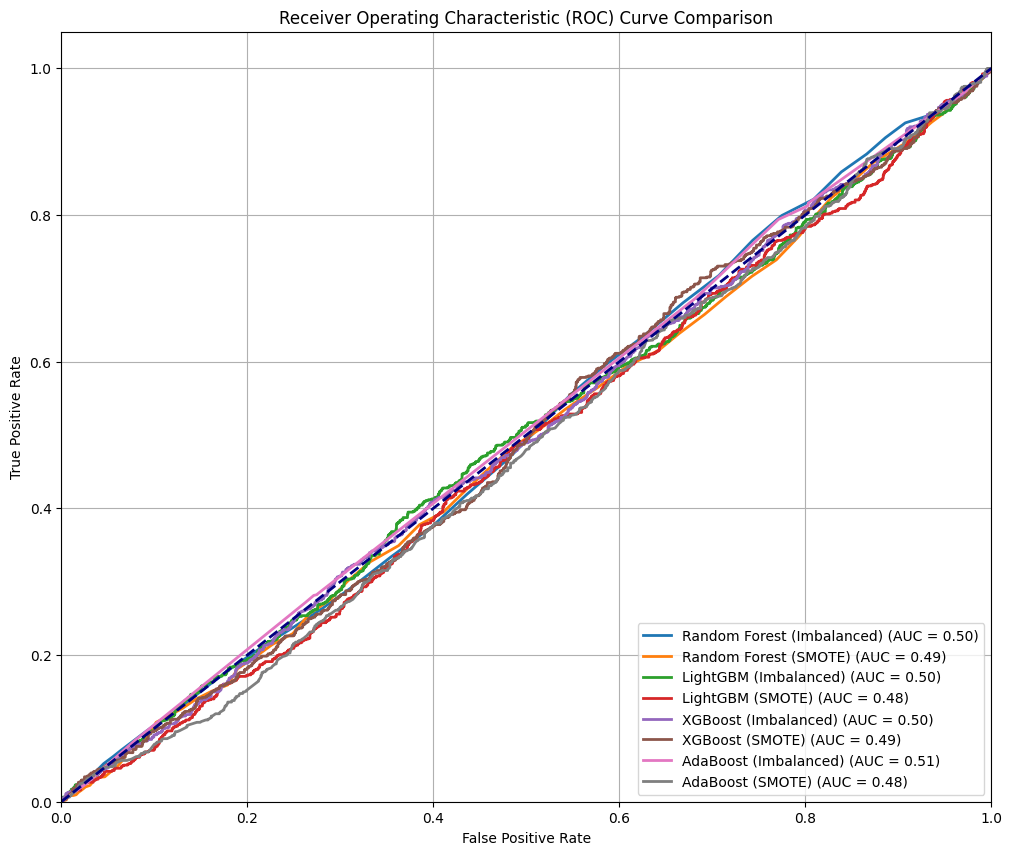

In [110]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Function to plot ROC curve for a given model
def plot_roc_curve(model, X_test, y_test, label):
    try:
        # Some models (like AdaBoost on imbalanced data) might not predict any positive class,
        # leading to an error in predict_proba or roc_curve. Handle this.
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            # For models that only have predict, it's problematic for ROC curve.
            # We'll use predict directly and assume binary output if predict_proba is missing.
            # This is a simplification and might not be ideal for true ROC analysis.
            y_pred_proba = model.predict(X_test)
            if np.all(y_pred_proba == 0) or np.all(y_pred_proba == 1):
                print(f"Warning: {label} made only one class prediction. Skipping ROC curve.")
                return

        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')
    except Exception as e:
        print(f"Could not plot ROC curve for {label}: {e}")


# Random Forest - Imbalanced
plot_roc_curve(model, X_test, y_test, 'Random Forest (Imbalanced)')

# Random Forest - SMOTE
plot_roc_curve(model_resampled_rf, X_test, y_test, 'Random Forest (SMOTE)')

# LightGBM - Imbalanced
plot_roc_curve(lgbm_model, X_test, y_test, 'LightGBM (Imbalanced)')

# LightGBM - SMOTE
plot_roc_curve(lgbm_model_resampled, X_test, y_test, 'LightGBM (SMOTE)')

# XGBoost - Imbalanced
plot_roc_curve(xgb_model, X_test, y_test, 'XGBoost (Imbalanced)')

# XGBoost - SMOTE
plot_roc_curve(xgb_model_resampled, X_test, y_test, 'XGBoost (SMOTE)')

# AdaBoost - Imbalanced (will likely fail due to 0 recall)
plot_roc_curve(adaboost_model, X_test, y_test, 'AdaBoost (Imbalanced)')

# AdaBoost - SMOTE
plot_roc_curve(adaboost_model_resampled, X_test, y_test, 'AdaBoost (SMOTE)')


plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Training GradientBoostingClassifier on Original Imbalanced Data

Now, let's train a `GradientBoostingClassifier` using the original, imbalanced training data (`X_train`, `y_train`) and evaluate its performance.

In [111]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the GradientBoostingClassifier on original data
gbc_model = GradientBoostingClassifier(random_state=42)
gbc_model.fit(X_train, y_train)

# Make predictions on the test set
gbc_y_pred = gbc_model.predict(X_test)

# Evaluate the GradientBoostingClassifier model
print("GradientBoostingClassifier Performance (Original Data):")
print(f"Accuracy: {accuracy_score(y_test, gbc_y_pred):.4f}")
print(f"Precision: {precision_score(y_test, gbc_y_pred):.4f}")
print(f"Recall: {recall_score(y_test, gbc_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, gbc_y_pred):.4f}")

print("\nGradientBoostingClassifier Confusion Matrix (Original Data):")
print(confusion_matrix(y_test, gbc_y_pred))

print("\nGradientBoostingClassifier Classification Report (Original Data):")
print(classification_report(y_test, gbc_y_pred))

GradientBoostingClassifier Performance (Original Data):
Accuracy: 0.6386
Precision: 0.4048
Recall: 0.0180
F1-Score: 0.0346

GradientBoostingClassifier Confusion Matrix (Original Data):
[[1662   25]
 [ 925   17]]

GradientBoostingClassifier Classification Report (Original Data):
              precision    recall  f1-score   support

           0       0.64      0.99      0.78      1687
           1       0.40      0.02      0.03       942

    accuracy                           0.64      2629
   macro avg       0.52      0.50      0.41      2629
weighted avg       0.56      0.64      0.51      2629



### Training GradientBoostingClassifier on SMOTE-Balanced Data

Next, I will train a `GradientBoostingClassifier` using the SMOTE-resampled training data (`X_train_res`, `y_train_res`) and evaluate its performance to see the impact of balancing.

In [112]:
# Initialize and train the GradientBoostingClassifier on resampled data
gbc_model_resampled = GradientBoostingClassifier(random_state=42)
gbc_model_resampled.fit(X_train_res, y_train_res)

# Make predictions on the test set
gbc_y_pred_resampled = gbc_model_resampled.predict(X_test)

# Evaluate the GradientBoostingClassifier model
print("GradientBoostingClassifier Performance (After SMOTE):")
print(f"Accuracy: {accuracy_score(y_test, gbc_y_pred_resampled):.4f}")
print(f"Precision: {precision_score(y_test, gbc_y_pred_resampled):.4f}")
print(f"Recall: {recall_score(y_test, gbc_y_pred_resampled):.4f}")
print(f"F1-Score: {f1_score(y_test, gbc_y_pred_resampled):.4f}")

print("\nGradientBoostingClassifier Confusion Matrix (After SMOTE):")
print(confusion_matrix(y_test, gbc_y_pred_resampled))

print("\nGradientBoostingClassifier Classification Report (After SMOTE):")
print(classification_report(y_test, gbc_y_pred_resampled))

GradientBoostingClassifier Performance (After SMOTE):
Accuracy: 0.5150
Precision: 0.3382
Recall: 0.3694
F1-Score: 0.3531

GradientBoostingClassifier Confusion Matrix (After SMOTE):
[[1006  681]
 [ 594  348]]

GradientBoostingClassifier Classification Report (After SMOTE):
              precision    recall  f1-score   support

           0       0.63      0.60      0.61      1687
           1       0.34      0.37      0.35       942

    accuracy                           0.52      2629
   macro avg       0.48      0.48      0.48      2629
weighted avg       0.52      0.52      0.52      2629



In [115]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# Prepare the 'another' DataFrame
X_another = another.drop('heart_attack_risk', axis=1)
y_another = another['heart_attack_risk']

# Identify categorical features in X_another
categorical_features_another = X_another.select_dtypes(include=['object', 'category']).columns.tolist()

# One-hot encode categorical features
X_another_encoded = pd.get_dummies(X_another, columns=categorical_features_another, drop_first=True)

# Split the data into training and testing sets
X_train_another, X_test_another, y_train_another, y_test_another = train_test_split(
    X_another_encoded, y_another, test_size=0.3, random_state=42, stratify=y_another
)

# Apply SMOTE to balance the training data
sm = SMOTE(random_state=42)
X_train_another_res, y_train_another_res = sm.fit_resample(X_train_another, y_train_another)

print(f"Original training set shape for 'another': X_train={X_train_another.shape}, y_train={y_train_another.shape}")
print(f"Original class distribution in training set for 'another':\n{y_train_another.value_counts()}")
print(f"Resampled training set shape for 'another': X_train_res={X_train_another_res.shape}, y_train_res={y_train_another_res.shape}")
print(f"Resampled class distribution in training set for 'another':\n{y_train_another_res.value_counts()}")

# Initialize and train the CatBoost Classifier on resampled data
cat_model = CatBoostClassifier(random_state=42, verbose=0,  # verbose=0 to suppress training output
                               eval_metric='F1', # Optimize for F1-score
                               class_weights=[1, y_train_another.value_counts()[0]/y_train_another.value_counts()[1]]
                              )
cat_model.fit(X_train_another_res, y_train_another_res)

# Make predictions on the original test set
cat_y_pred = cat_model.predict(X_test_another)

# Evaluate the CatBoost model
print("\nCatBoost Classifier Performance (After SMOTE on 'another' dataframe):")
print(f"Accuracy: {accuracy_score(y_test_another, cat_y_pred):.4f}")
print(f"Precision: {precision_score(y_test_another, cat_y_pred):.4f}")
print(f"Recall: {recall_score(y_test_another, cat_y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test_another, cat_y_pred):.4f}")

print("\nCatBoost Confusion Matrix (After SMOTE on 'another' dataframe):")
print(confusion_matrix(y_test_another, cat_y_pred))

print("\nCatBoost Classification Report (After SMOTE on 'another' dataframe):")
print(classification_report(y_test_another, cat_y_pred))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00
Original training set shape for 'another': X_train=(6134, 34), y_train=(6134,)
Original class distribution in training set for 'another':
heart_attack_risk
0    3937
1    2197
Name: count, dtype: int64
Resampled training set shape for 'another': X_train_res=(7874, 34), y_train_res=(7874,)
Resampled class distribution in training set for 'another':
heart_attack_risk
1    3937
0    3937
Name: count, dtype: int64

CatBoost Classifier Performance (After SMOTE on 'another' dataframe):
Accuracy: 0.4728
Precision: 0.3522
Recall: 0.5616
F1-Score: 0.4329

CatBoost Confusion Matrix (After SMOTE on 'another' dataframe):
[[714 973]
 [413 529]]

CatBoost Classification Report (After SMOTE on 'another' dataframe):
              precision    recall  f1-score   support

           0       0.63      0.42      0.51      1687
           1       0.35      0.56      0.43       942

    accuracy                           0.47     